# Matplotlib 학습 정리

이 노트북은 여러 개의 실습 스크립트를 하나로 묶어, **Matplotlib 기본 사용법 → 그래프 종류별 예제 → 스타일 커스터마이징 → pandas 연계** 흐름으로 다시 정리한 버전입니다.

학습 포인트는 다음과 같습니다.

- `plt.plot()`으로 기본 선 그래프 그리기
- 산점도, 막대그래프, 히스토그램, 파이차트 등 자주 쓰는 그래프 익히기
- `subplot`, `subplots`로 여러 그래프를 한 화면에 배치하기
- 제목, 축 라벨, 범례, 격자, 마커, 색상, 투명도 등 시각 요소 조정하기
- 한글 폰트 설정과 음수 깨짐 방지 처리 이해하기
- pandas `DataFrame`과 연결해 반복 시각화 자동화하기


In [1]:
import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## 1. 한글 폰트 설정 함수

원본 코드들에서 반복되던 한글 폰트 설정 부분은 공통 함수로 정리할 수 있습니다.

이 함수는 다음 순서로 동작합니다.

1. `axes.unicode_minus=False`로 음수 부호 깨짐을 방지합니다.
2. 시스템에 원하는 폰트가 있으면 그 폰트를 사용합니다.
3. 시스템 폰트가 없으면 로컬 폰트 파일 경로를 확인해서 적용합니다.
4. 둘 다 없으면 경고만 출력하고 기본 폰트로 진행합니다.


In [ ]:
def setup_korean_font(
    prefer_family: str = 'NanumGothic',
    local_font_path: str = './fonts/NanumGothic.ttf',
    local_bold_path: str = './fonts/NanumGothicBold.ttf'
):
    mpl.rc('axes', unicode_minus=False)
    mpl.rc('font', family=prefer_family)

    available = {f.name for f in fm.fontManager.ttflist}
    if prefer_family not in available:
        if os.path.exists(local_font_path):
            font_prop = fm.FontProperties(fname=local_font_path)
            mpl.rcParams['font.family'] = font_prop.get_name()
        elif os.path.exists(local_bold_path):
            font_prop = fm.FontProperties(fname=local_bold_path)
            mpl.rcParams['font.family'] = font_prop.get_name()
        else:
            print('[WARN] 한글 폰트가 시스템 또는 로컬 위치에 모두 존재하지 않습니다.')


## 2. 기본 선 그래프

가장 기본적인 시작점은 `plot()`입니다.

- y값만 넣으면 x축은 `0, 1, 2, ...`처럼 자동 생성됩니다.
- x와 y를 함께 넣으면 원하는 축 값으로 직접 그릴 수 있습니다.


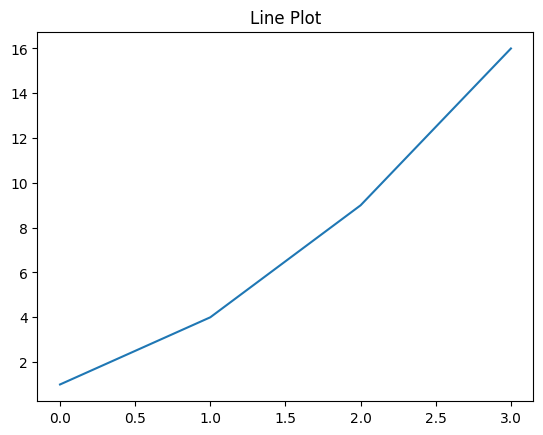

In [4]:
data = [1, 4, 9, 16]

plt.title('Line Plot')
plt.plot(data)
plt.show()

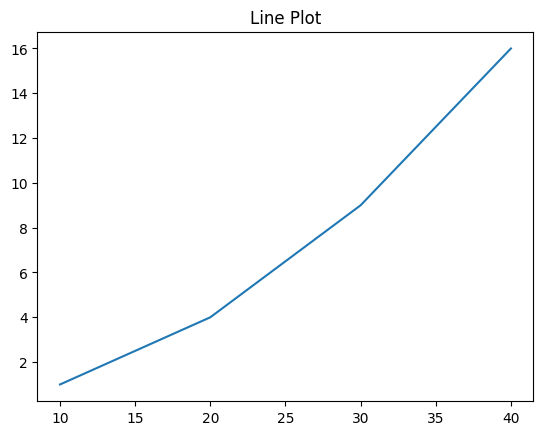

In [5]:
x_data = [10, 20, 30, 40]
y_data = [1, 4, 9, 16]

plt.title('Line Plot')
plt.plot(x_data, y_data)
plt.show()

## 3. 폰트와 텍스트 스타일

Matplotlib에서 한글이 깨지는 경우가 많기 때문에 폰트 설정은 초반에 익혀두는 것이 좋습니다.

아래 예제는 세 가지 방식으로 정리할 수 있습니다.

- 전역 설정으로 전체 그래프에 같은 폰트 적용
- 특정 텍스트 요소에만 `fontproperties` 적용
- `fontdict`로 제목/축 라벨 스타일을 각각 다르게 적용


In [ ]:
def test_fonts_info():
    print(mpl.matplotlib_fname())
    print(mpl.get_cachedir())


def test_fonts_global():
    print(mpl.rcParams['font.family'])
    print(mpl.rcParams['font.size'])

    mpl.rc('font', family='NanumGothic')
    mpl.rc('axes', unicode_minus=False)

    y_data = [1, 4, 9, 16]
    x_data = [10, 20, 30, 40]

    plt.title('한글 그래프 제목')
    plt.plot(x_data, y_data)
    plt.xlabel('x축 제목')
    plt.ylabel('y축 제목')
    plt.show()


def test_fonts_local_file():
    font_path = './fonts/NanumGothicBold.ttf'
    font_prop = fm.FontProperties(fname=font_path)

    y_data = [1, 4, 9, 16]
    x_data = [10, 20, 30, 40]

    plt.title('예제 그래프', fontproperties=font_prop)
    plt.plot(x_data, y_data)
    plt.xlabel('x축 제목', fontproperties=font_prop)
    plt.ylabel('y축 제목', fontproperties=font_prop)
    plt.show()


def test_fonts_fontdict():
    font1 = {'family': 'NanumGothic', 'size': 24, 'color': 'blue', 'weight': 'bold'}
    font2 = {'family': 'NanumGothic', 'size': 16, 'color': 'red', 'weight': 'bold'}
    font3 = {'family': 'NanumGothic', 'size': 12, 'color': 'green', 'weight': 'light'}

    y_data = [1, 4, 9, 16]
    x_data = [10, 20, 30, 40]

    plt.title('예제 그래프', fontdict=font1)
    plt.plot(x_data, y_data)
    plt.xlabel('x축 제목', fontdict=font2)
    plt.ylabel('y축 제목', fontdict=font3)
    plt.show()


## 5. 자주 쓰는 그래프 종류

실무나 학습에서 가장 자주 만나는 기본 그래프들을 한 번에 정리합니다.

- 여러 개의 선을 비교하는 선 그래프
- 점의 분포를 보는 산점도
- 범주별 값을 비교하는 세로/가로 막대그래프
- 데이터 분포를 보는 히스토그램
- 비율을 보여주는 파이차트


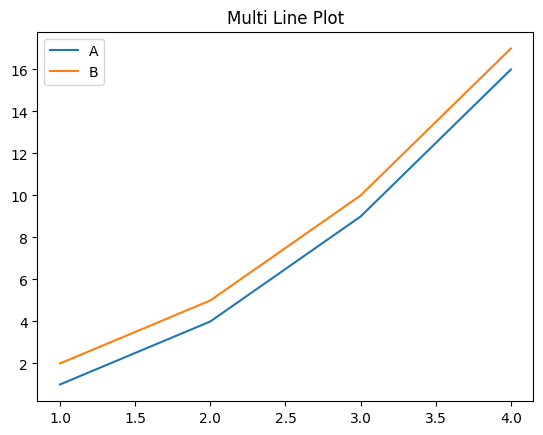

In [6]:
x = [1, 2, 3, 4]
y1 = [1, 4, 9, 16]
y2 = [2, 5, 10, 17]

plt.title('Multi Line Plot')
plt.plot(x, y1, label='A')
plt.plot(x, y2, label='B')
plt.legend()
plt.show()

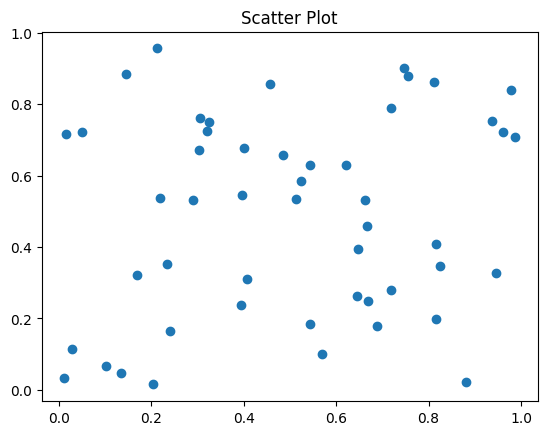

In [7]:
x = np.random.rand(50)
y = np.random.rand(50)

plt.title('Scatter Plot')
plt.scatter(x, y)
plt.show()

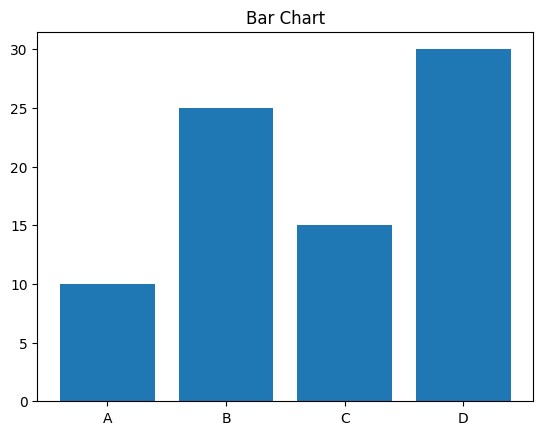

In [8]:
names = ['A', 'B', 'C', 'D']
values = [10, 25, 15, 30]

plt.title('Bar Chart')
plt.bar(names, values)
plt.show()

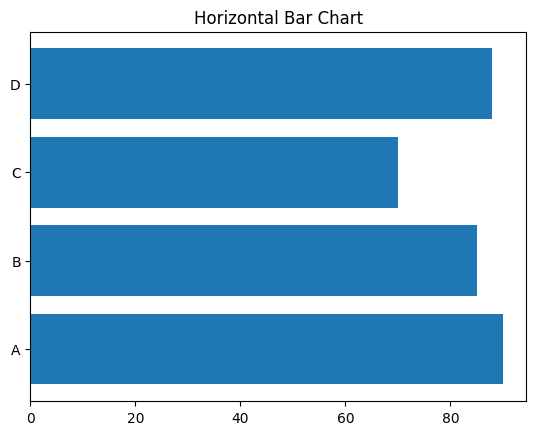

In [10]:
names = ['A', 'B', 'C', 'D']
values = [90, 85, 70, 88]

plt.title('Horizontal Bar Chart')
plt.barh(names, values)
plt.show()

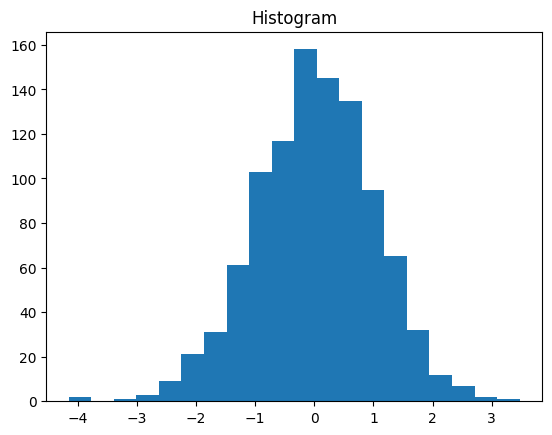

In [11]:
data = np.random.randn(1000)

plt.title('Histogram')
plt.hist(data, bins=20)
plt.show()

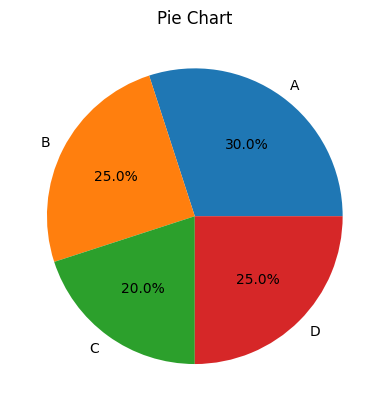

In [13]:
labels = ['A', 'B', 'C', 'D']
sizes = [30, 25, 20, 25]

plt.title('Pie Chart')
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.show()

## 6. 여러 그래프 배치하기

보고서나 대시보드 형태에서는 한 화면에 여러 그래프를 배치하는 경우가 많습니다.

Matplotlib에서는 두 가지 방식이 자주 사용됩니다.

- `plt.subplot()` : 빠르게 위치를 지정하는 방식
- `plt.subplots()` : `fig`, `axes` 객체를 받아 더 체계적으로 다루는 방식


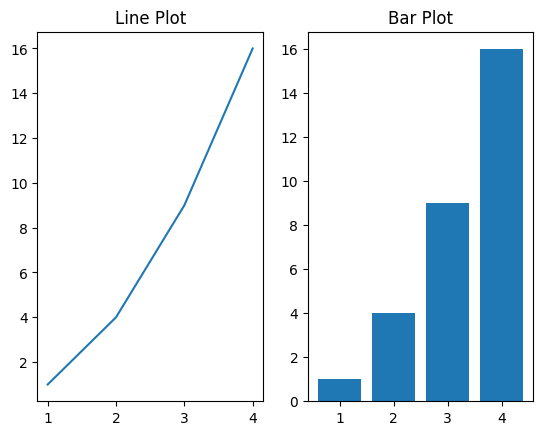

In [16]:
x = [1, 2, 3, 4]
y = [1, 4, 9, 16]

plt.subplot(1, 2, 1)
plt.title('Line Plot')
plt.plot(x, y)

plt.subplot(1, 2, 2)
plt.title('Bar Plot')
plt.bar(x, y)

plt.show()

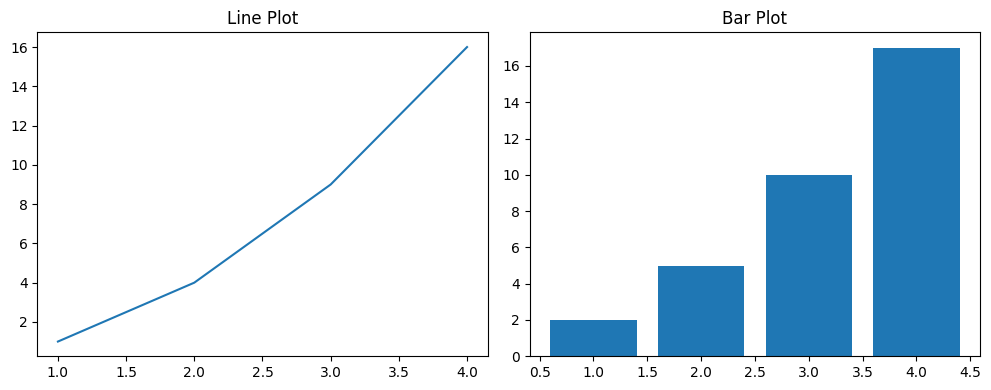

In [17]:
x = [1, 2, 3, 4]
y1 = [1, 4, 9, 16]
y2 = [2, 5, 10, 17]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(x, y1)
axes[0].set_title('Line Plot')

axes[1].bar(x, y2)
axes[1].set_title('Bar Plot')

plt.tight_layout()
plt.show()

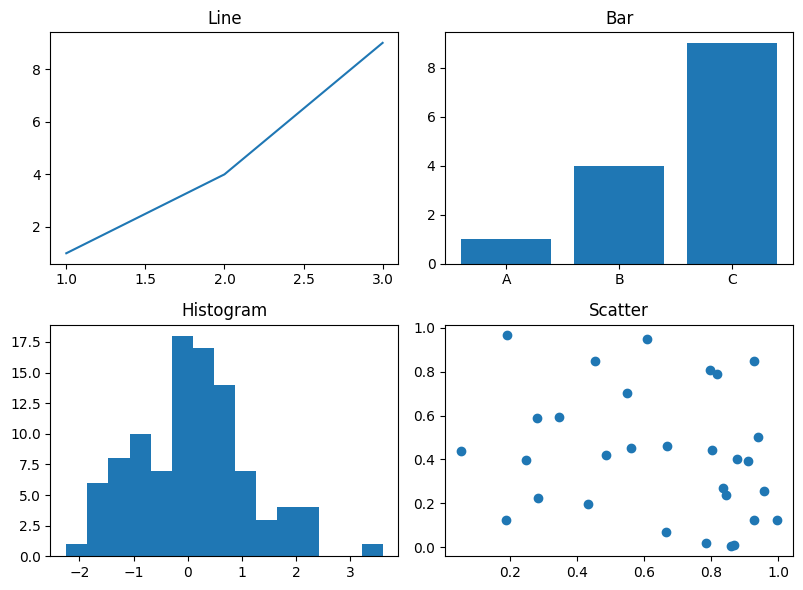

In [18]:
data = np.random.randn(100)

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

axes[0, 0].plot([1, 2, 3], [1, 4, 9])
axes[0, 0].set_title('Line')

axes[0, 1].bar(['A', 'B', 'C'], [1, 4, 9])
axes[0, 1].set_title('Bar')

axes[1, 0].hist(data, bins=15)
axes[1, 0].set_title('Histogram')

axes[1, 1].scatter(np.random.rand(30), np.random.rand(30))
axes[1, 1].set_title('Scatter')

plt.tight_layout()
plt.show()

## 7. 선 그래프 스타일 커스터마이징

선 그래프를 더 보기 좋게 만드는 옵션들이 있습니다.

특히 아래 옵션들은 거의 항상 자주 사용됩니다.

- `marker`: 데이터 포인트 모양
- `linestyle`: 선 종류
- `linewidth`: 선 두께
- `alpha`: 투명도
- `label` + `legend`: 범례 표시


In [ ]:
def test_line_detail():
    setup_korean_font()

    x = [1, 2, 3, 4, 5]
    y1 = [2, 3, 5, 7, 11]
    y2 = [1, 4, 6, 8, 9]

    plt.figure(figsize=(8, 4))

    plt.plot(x, y1, marker='o', linestyle='-', linewidth=2, alpha=0.9, label='소수 수열')
    plt.plot(x, y2, marker='s', linestyle='--', linewidth=2, alpha=0.7, label='비교 수열')

    plt.title('선 그래프: 마커/선스타일/투명도 적용 실습')
    plt.xlabel('x 값')
    plt.ylabel('y 값')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='best')
    plt.show()


## 8. 특정 지점 강조하기

그래프를 설명형으로 만들고 싶을 때는 중요한 값에 주석을 다는 것이 좋습니다.

여기서는 두 가지 방법을 사용합니다.

- `annotate()` : 화살표와 함께 설명 추가
- `text()` : 간단한 텍스트만 좌표에 출력


In [ ]:
def test_line_annotate_specific_points():
    setup_korean_font()

    x = list(range(1, 11))
    y = [v * v - 3 * v + 5 for v in x]

    plt.figure(figsize=(8, 4))
    plt.plot(x, y, marker='D', linestyle='-', linewidth=2)

    plt.title('선그래프: 특정 값만 라벨(annotate)')
    plt.xlabel('x')
    plt.ylabel('y')

    max_idx = max(range(len(y)), key=lambda i: y[i])
    max_x, max_y = x[max_idx], y[max_idx]

    plt.annotate(
        text=f'최대값: {max_y}',
        xy=(max_x, max_y),
        xytext=(10, 20),
        textcoords='offset points',
        arrowprops=dict(arrowstyle='->', linewidth=1.5)
    )

    for xi, yi in zip(x, y):
        if yi >= 50:
            plt.text(xi, yi, str(yi))

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()


## 9. 막대그래프 꾸미기

막대그래프는 단순 비교뿐 아니라 보고서 스타일로도 자주 쓰입니다.

원본 예제에서 중요한 포인트는 다음과 같습니다.

- 막대별 색상을 다르게 줄 수 있음
- 테두리(`edgecolor`)를 줄 수 있음
- 무늬(`hatch`)를 적용할 수 있음
- 막대 위에 실제 값을 텍스트로 표시할 수 있음


In [ ]:
def test_bar_colors_each_hatch():
    setup_korean_font()

    categories = ['A', 'B', 'C', 'D', 'E']
    values = [5, 2, 7, 4, 6]
    colors = ['red', 'orange', 'green', 'blue', 'purple']
    hatches = ['/', '\', 'x', '-', 'o']

    plt.figure(figsize=(8, 4))
    bars = plt.bar(categories, values, color=colors, edgecolor='black', linewidth=1.2)

    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)

    plt.title('막대 그래프: 막대별 색상/무늬/테두리 적용')
    plt.xlabel('카테고리')
    plt.ylabel('값')
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.show()


def test_bar_value_labels_ylim():
    setup_korean_font()

    x = ['1분기', '2분기', '3분기', '4분기']
    y = [120, 80, 150, 130]

    plt.figure(figsize=(8, 4))
    bars = plt.bar(x, y, color='skyblue', edgecolor='black')

    for bar in bars:
        h = bar.get_height()
        cx = bar.get_x() + bar.get_width() / 2
        plt.text(cx, h, f'{h}', ha='center', va='bottom')

    plt.title('막대 그래프: 값 라벨 + y축 범위 조정')
    plt.xlabel('분기')
    plt.ylabel('매출')
    plt.ylim(0, max(y) * 1.2)
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.show()


## 10. 파이차트와 도넛차트

파이차트는 비율을 보여줄 때 사용하지만, 항목이 너무 많아지면 가독성이 떨어질 수 있습니다.

그래도 학습 관점에서는 다음 옵션을 익혀두면 좋습니다.

- `explode`: 특정 조각 강조
- `autopct`: 퍼센트 표시 형식
- `startangle`: 시작 각도
- `wedgeprops=dict(width=...)`: 도넛 형태 만들기


In [ ]:
def test_pie_explode_autopct():
    setup_korean_font()

    labels = ['국어', '영어', '수학', '과학']
    sizes = [30, 25, 35, 10]
    explode = [0, 0.12, 0, 0]

    plt.figure(figsize=(6, 6))
    plt.pie(sizes, labels=labels, explode=explode, autopct='%1.1f%%', startangle=90, shadow=True)
    plt.title('파이 차트: explode + autopct + shadow')
    plt.show()


def test_pie_donut_style():
    setup_korean_font()

    labels = ['A', 'B', 'C', 'D']
    sizes = [40, 20, 25, 15]

    plt.figure(figsize=(6, 6))
    plt.pie(sizes, labels=labels, autopct='%1.0f%%', startangle=90, wedgeprops=dict(width=0.4))
    plt.title('파이 차트: 도넛 스타일')
    plt.show()


## 11. 산점도 확장 옵션

산점도는 단순히 점만 찍는 것보다, 점 크기나 기준선을 함께 쓰면 훨씬 설명력이 좋아집니다.

이 예제에서는 다음을 사용합니다.

- `s`: 점 크기
- `alpha`: 투명도
- `marker`: 점 모양
- 기준선 추가용 `plot()`


In [ ]:
def test_scatter_size_alpha_marker():
    setup_korean_font()

    x = [1, 2, 3, 4, 5, 6]
    y = [2, 1, 3, 5, 4, 6]
    sizes = [30, 60, 90, 120, 150, 180]

    plt.figure(figsize=(8, 4))
    plt.scatter(x, y, s=sizes, alpha=0.7, marker='^')
    plt.plot([1, 6], [1, 6], linestyle='--', linewidth=1.5)

    plt.title('산점도: 점 크기(s) + 투명도(alpha) + 기준선')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()


## 12. pandas와 함께 사용하기

`matplotlib`는 pandas와 함께 사용할 때 특히 강력합니다.

원본 코드에서는 다음 흐름을 연습하고 있습니다.

1. CSV를 읽어서 `DataFrame` 생성
2. 수치형 컬럼만 자동 추출
3. 컬럼 개수에 맞춰 subplot 개수 자동 생성
4. 히스토그램, 박스플롯, 그룹 평균 막대그래프 생성


In [ ]:
def test_csv_load(csv_path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    print(df.head())
    print(df.info())
    return df


def get_numeric_columns(df):
    numeric_cols = df.select_dtypes(include='number').columns
    print('Numeric columns : ', list(numeric_cols))
    return numeric_cols


def test_dataframe_hist_subplot(df):
    numeric_cols = get_numeric_columns(df)
    col_cnt = len(numeric_cols)

    fig, axes = plt.subplots(col_cnt, 1, figsize=(6, 4 * col_cnt))

    if col_cnt == 1:
        axes = [axes]

    for ax, col in zip(axes, numeric_cols):
        ax.hist(df[col], bins=10)
        ax.set_title(f'{col} Histogram')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')

    plt.tight_layout()
    plt.show()


def test_dataframe_boxplot_subplot(df):
    numeric_cols = get_numeric_columns(df)
    col_cnt = len(numeric_cols)

    fig, axes = plt.subplots(1, col_cnt, figsize=(5 * col_cnt, 4))

    if col_cnt == 1:
        axes = [axes]

    for ax, col in zip(axes, numeric_cols):
        ax.boxplot(df[col])
        ax.set_title(f'{col} Boxplot')
        ax.set_ylabel(col)

    plt.tight_layout()
    plt.show()


def test_dataframe_groupby_subplot(df, category_col):
    numeric_cols = get_numeric_columns(df)
    grouped = df.groupby(category_col)[numeric_cols].mean()

    grouped.plot(kind='bar', figsize=(8, 4), title=f'Average by {category_col}')
    plt.ylabel('Mean Value')
    plt.show()


## 13. 추천 실행 순서

처음 복습할 때는 아래 순서로 실행하면 흐름이 잘 잡힙니다.

1. `test_plot1()`, `test_plot2()`로 기본 구조 익히기
2. `test_multiline_plot()`, `test_bar_plot()`, `test_scatter_plot()`로 그래프 종류 익히기
3. `test_subplots_object()`, `test_subplot_2by2()`로 다중 배치 익히기
4. `test_line_detail()`, `test_bar_value_labels_ylim()`로 꾸미기 옵션 익히기
5. 마지막에 pandas 연계 함수들로 자동화 감각 익히기
